In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

In [ ]:
# generate reproducable non linear data
np.random.seed(42)
X = np.linspace(0,10,40).reshape(-1,1)

y = 2+ 0.5 * X[:,0]**2 + np.random.normal(0,5,40)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


degrees = [1,2,10]

for degree in degrees:
  model = make_pipeline(PolynomialFeatures(degree,include_bias = False), LinearRegression())

  model.fit(X_train, y_train)
  train_prediction = model.predict(X_train)
  test_prediction = model.predict(X_test)

  train_mse = mean_squared_error(y_train,train_prediction)
  test_mse = mean_squared_error(y_test,test_prediction)

  print(f"Polynomial degree: {degree}")
  print(f"Training MSE: {train_mse:.2f}")
  print(f"Test MSE: {test_mse:.2f}")



Polynomial degree: 1
Training MSE: 42.90
Test MSE: 42.99
Polynomial degree: 2
Training MSE: 20.44
Test MSE: 19.79
Polynomial degree: 10
Training MSE: 12.89
Test MSE: 95.21


degree 1: the mse is both high in train and test, model is too simple so it is underfitting, high bias low variance

degree 2: mse is low for both, model is optimal

degree 10: mse is low for train high for test, means model is too complex and hence it is overfitting



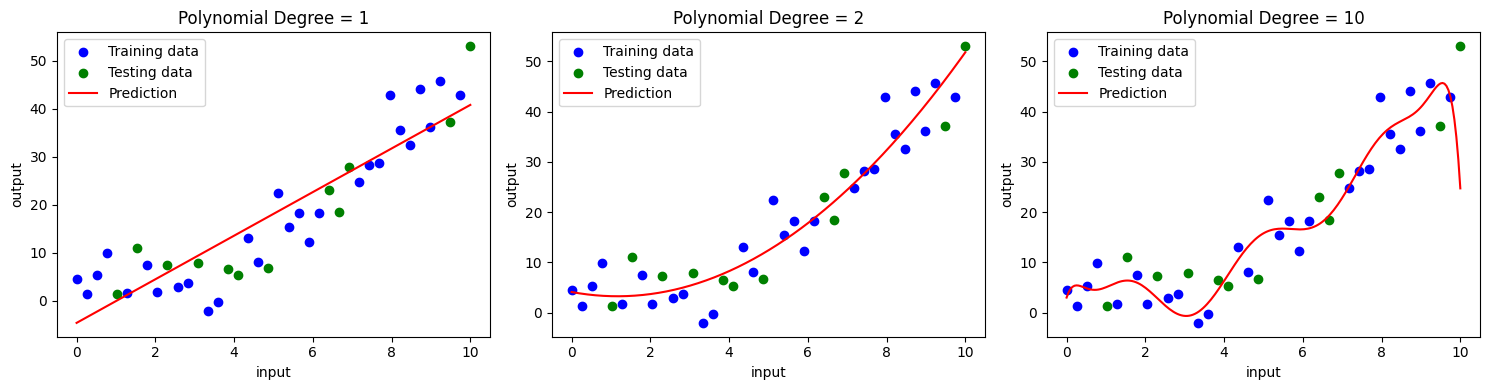

In [ ]:
X_plot = np.linspace(0,10,200).reshape(-1,1)
plt.figure(figsize = (15,4))
for index, degree in enumerate(degrees):
  model = make_pipeline(PolynomialFeatures(degree = degree, include_bias = False), LinearRegression())

  model.fit(X_train, y_train)
  y_plot = model.predict(X_plot)

  plt.subplot(1,3,index+1)
  plt.scatter(X_train,y_train,color = "blue",label = "Training data")
  plt.scatter(X_test,y_test,color = "green", label = "Testing data")
  plt.plot(X_plot,y_plot,color = "red", label = "Prediction")

  plt.title(f"Polynomial Degree = {degree}")
  plt.xlabel("input")
  plt.ylabel("output")
  plt.legend()
plt.tight_layout()
plt.show()


# Cross validation and model selection

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import numpy as np

for degree in range(1,11):
  model = make_pipeline(
      PolynomialFeatures(degree = degree, include_bias = False),LinearRegression()
  )

  scores = cross_val_score(
      model,
      X,
      y,
      scoring = "neg_mean_squared_error",
      cv = 5
  )

  mean_mse = -scores.mean()
  print(f"Degree{degree}: CV MSE = {mean_mse:.2f}")



Degree1: CV MSE = 110.69
Degree2: CV MSE = 44.22
Degree3: CV MSE = 71.23
Degree4: CV MSE = 82.46
Degree5: CV MSE = 1348.27
Degree6: CV MSE = 11392.13
Degree7: CV MSE = 53226.76
Degree8: CV MSE = 99956.80
Degree9: CV MSE = 1196598.07
Degree10: CV MSE = 11490574.52


#Feature selection

In [ ]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

X = pd.DataFrame({
    "constant_feature": [1,1,1,1,1],
    "almost_constant": [0,0,0,0,1],
    "useful_feature": [10,20,30,40,50]
})

selector = VarianceThreshold(threshold = 0.0)
X_selected = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()]
print("selected features:",list(selected_columns))

selected features: ['almost_constant', 'useful_feature']


In [ ]:
X = pd.DataFrame({
    "constant_feature": [1,1,1,1,1],
    "almost_constant": [0,0,0,0,1],
    "useful_feature": [10,20,30,40,50]
})

selector = VarianceThreshold(threshold = 0.2)  # changeing threshol to this to remove low variance column as well
X_selected = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()]
print("selected features:",list(selected_columns))

selected features: ['useful_feature']


# Correlation among features

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "study_hours": [1,2,3,4,5,6],
    "attendance": [50,55,65,70,80,90],
    "previous_marks": [25,40,50,55,65,75],
    "final_marks": [38,45,52,60,70,82]
})

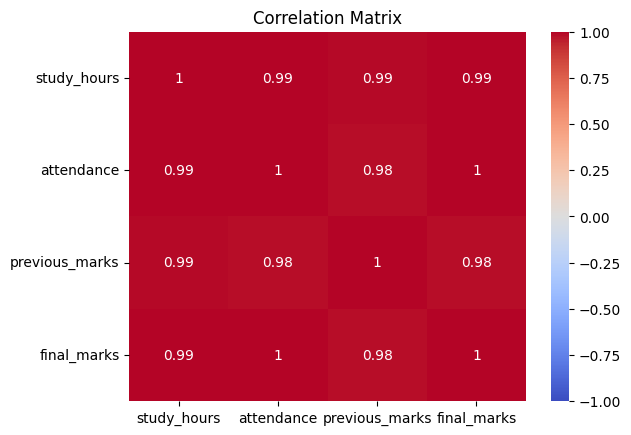

In [ ]:
correlation_matrix = data.corr(numeric_only = True)
sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = "coolwarm",
    vmin = -1,
    vmax = 1
)

plt.title("Correlation Matrix")
plt.show()

#Chi square test

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

data = load_breast_cancer()
X = data.data
y = data.target

X_non_negative = MinMaxScaler().fit_transform(X)

selector = SelectKBest(score_func = chi2, k = 5)
X_selected = selector.fit_transform(X_non_negative,y)

selected_features = data.feature_names[selector.get_support()]

print("Selected features:")
print(selected_features)

Selected features:
['mean concavity' 'mean concave points' 'worst perimeter' 'worst area'
 'worst concave points']


#univariant feature selection


In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.datasets import load_iris


In [ ]:
iris = load_iris()
X,y = iris.data, iris.target


In [ ]:
X_select = SelectKBest(chi2, k =3).fit_transform(X,y)
X_select

array([[5.1, 1.4, 0.2],
       [4.9, 1.4, 0.2],
       [4.7, 1.3, 0.2],
       [4.6, 1.5, 0.2],
       [5. , 1.4, 0.2],
       [5.4, 1.7, 0.4],
       [4.6, 1.4, 0.3],
       [5. , 1.5, 0.2],
       [4.4, 1.4, 0.2],
       [4.9, 1.5, 0.1],
       [5.4, 1.5, 0.2],
       [4.8, 1.6, 0.2],
       [4.8, 1.4, 0.1],
       [4.3, 1.1, 0.1],
       [5.8, 1.2, 0.2],
       [5.7, 1.5, 0.4],
       [5.4, 1.3, 0.4],
       [5.1, 1.4, 0.3],
       [5.7, 1.7, 0.3],
       [5.1, 1.5, 0.3],
       [5.4, 1.7, 0.2],
       [5.1, 1.5, 0.4],
       [4.6, 1. , 0.2],
       [5.1, 1.7, 0.5],
       [4.8, 1.9, 0.2],
       [5. , 1.6, 0.2],
       [5. , 1.6, 0.4],
       [5.2, 1.5, 0.2],
       [5.2, 1.4, 0.2],
       [4.7, 1.6, 0.2],
       [4.8, 1.6, 0.2],
       [5.4, 1.5, 0.4],
       [5.2, 1.5, 0.1],
       [5.5, 1.4, 0.2],
       [4.9, 1.5, 0.2],
       [5. , 1.2, 0.2],
       [5.5, 1.3, 0.2],
       [4.9, 1.4, 0.1],
       [4.4, 1.3, 0.2],
       [5.1, 1.5, 0.2],
       [5. , 1.3, 0.3],
       [4.5, 1.3

# how does anova f test works|

In [ ]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, f_classif
data = load_iris()
X = data.data
y = data.target
selector = SelectKBest(f_classif, k = 2)
X_selected = selector.fit_transform(X,y)

import numpy as np
selected_features = np.array(data.feature_names)[selector.get_support()]
print("Selected features:", selected_features)

Selected features: ['petal length (cm)' 'petal width (cm)']


#performing chi 2 test and variance threshold
 on data1 and data2 check datasset folder


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/data-1.csv")

In [ ]:
df.describe()

,offer,Age,online payment,items
count,5.0,5.000000,5.0,5.000000
mean,1.0,34.800000,0.0,6.200000
std,0.0,5.630275,0.0,3.114482
min,1.0,26.000000,0.0,3.000000
25%,1.0,34.000000,0.0,4.000000
50%,1.0,35.000000,0.0,5.000000
75%,1.0,38.000000,0.0,9.000000
max,1.0,41.000000,0.0,10.000000


In [ ]:
from sklearn.feature_selection import VarianceThreshold

In [ ]:
variance_list = [0.0,0.1,0.17,0.2,0.3]
for i in variance_list:
  selector = VarianceThreshold(threshold = i)
  X_selected = selector.fit_transform(df)
  selected_columns = df.columns[selector.get_support()]
  print("for threshold:",i)
  print("selected features:",list(selected_columns))

for threshold: 0.0
selected features: ['Age', 'items']
for threshold: 0.1
selected features: ['Age', 'items']
for threshold: 0.17
selected features: ['Age', 'items']
for threshold: 0.2
selected features: ['Age', 'items']
for threshold: 0.3
selected features: ['Age', 'items']


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df_2 = pd.read_csv("/content/data-2.csv")

In [ ]:
df_2.describe()

,referred,repeat,Age,Promoted,items
count,6.000000,6.000000,6.000000,6.000000,6.000000
mean,0.833333,0.166667,35.666667,0.500000,6.333333
std,0.408248,0.408248,5.465040,0.547723,2.804758
min,0.000000,0.000000,26.000000,0.000000,3.000000
25%,1.000000,0.000000,34.250000,0.000000,4.250000
50%,1.000000,0.000000,36.500000,0.500000,6.000000
75%,1.000000,0.000000,39.500000,1.000000,8.500000
max,1.000000,1.000000,41.000000,1.000000,10.000000


In [ ]:
variance_list = [0.0,0.1,0.17,0.2,0.3]
for i in variance_list:
  selector = VarianceThreshold(threshold = i)
  X_selected = selector.fit_transform(df_2)
  selected_columns = df_2.columns[selector.get_support()]
  print("for threshold:",i)
  print("selected features:",list(selected_columns))

for threshold: 0.0
selected features: ['referred', 'repeat', 'Age', 'Promoted', 'items']
for threshold: 0.1
selected features: ['referred', 'repeat', 'Age', 'Promoted', 'items']
for threshold: 0.17
selected features: ['Age', 'Promoted', 'items']
for threshold: 0.2
selected features: ['Age', 'Promoted', 'items']
for threshold: 0.3
selected features: ['Age', 'items']
